# Deep Learning para detección automática de COVID

En este proyecto, utilizaremos el dataset [COVID-19 Radiography Database](https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database/data) de Kaggle, es cual nos proporciona imágenes obtenidas mediante radiografías pertenecientes a tres tipos de pacientes diferentes: pacientes de control, sin ningún tipo de patoligía, pacientes de COVID-19 y pacientes con neumonía vírica.

*Nota: notebook adaptado y traducido del usuario de Kaggle [Ahmed Hafez](https://www.kaggle.com/code/ahmedtronic/covid-19-radiology-vgg19-f1-score-95)*

In [6]:
# Nota: no hay por qué utilizar las librerías aquí puestas. Se pueden añadir/quitar
from IPython import display
import os
import math
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random as python_random
import tensorflow as tf
import seaborn as sns
import math
from sklearn.metrics import classification_report, confusion_matrix #, plot_confusion_matrix

np.random.seed(42)
tf.random.set_seed(42)

La siguiente celda es para poder leer los datos directamente desde Google Colab. Si el alumno utiliza otra plataforma, se deberá saltar este paso y adaptar los PATHs a las carpetas de train y test.

In [7]:
# from google.colab import drive
# drive.mount('/content/drive')

En la siguiente celda, se define el PATH a nuestros datos. Aquí debemos adaptarlo en función dónde lo tengamos guardado. Si tenemos nuestra carpeta con los materiales *Máster DL - IEP* en la página de inicio de nuestro Drive, el siguiente PATH debería valernos.

*Nota: si no se utiliza Google Colab, se pueden utilizar paths relativos.*

In [8]:
# PATH = "drive/MyDrive/Máster DL - IEP/"

Tras haber importado las librerías necesarias, vamos a generar un código que nos permita preprocesar las imágenes. Para ello, creamos la función *generate_data()*, a la cual le pasaremos el directorio donde tenemos almacenadas las imágenes.

Aquí encontramos la clase *ImageDataGenerator*, que ya hemos utilizado en notebooks anteriores. Veamos paso a paso lo que hacemos dentro de la función. Lo primero, es crear el objeto de la clase *ImageDataGenerator*, con la línea

```
datagen = ImageDataGenerator(rescale=1./255.)
```

donde lo único que les estamos indicando es que nos reescale las imágenes, como ya hemos hecho durante el curso, haciendo que el valor de cada píxel vaya de 0 a 1 en lugar de ir desde 0 a 255. Aquí es donde debemos darnos cuenta de que no estamos llevando a cabo ningún tipo de *Data Augmentation*. Cuando queremos generar el flujo de imágenes para aplicar el generador a nuestras imágenes, usamos

```
generator = datagen.flow_from_directory(DIR,
                                        batch_size=batch_size,
                                        shuffle=True,
                                        seed=42,
                                        class_mode='binary',
                                        target_size=(height, width),
                                        classes={'Normal': 0, 'Viral Pneumonia': 1,'Covid': 2})
```

Donde los parámetros más importantes para nosotros son:

- DIR es la carpeta donde están nuestras imágenes, a las cuales se aplicará el generador que hemos creado.
- batch_size es el tamaño del batch, que hemos definido anteriormente como 64.
- shuffle=True nos indica que el orden de los datos será aleatorio.
- target_size es el tamaño al que queremos reescalar las imágenes para adaptarlo a nuestro modelo, en nuestro caso 224x244 píxeles.
- classes es un diccionario para asignar a cada clase una etiqueta numérica. Así, posteriormente podremos entrenar nuestra red neuronal.

Tras ello, aplicamos el generador a nuestros conjuntos de entrenamiento y de test, obteniendo *test_generator* y *train_generator*.


In [ ]:
# ImageDataGenerator
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import cv2
from PIL import ImageFilter

height, width = 224, 224
batch_size=64

def generate_data(DIR):
    datagen = ImageDataGenerator(rescale=1./255.)

    generator = datagen.flow_from_directory(
        DIR,
        batch_size=batch_size,
        shuffle=True,
        seed=42,
        class_mode='binary',
        target_size=(height, width),
        classes={'Normal': 0, 'Viral Pneumonia': 1,'Covid': 2}
    )
    return generator

TRAINING_DIR = 'Covid19-dataset/train'
TESTING_DIR = 'Covid19-dataset/test'

train_generator = generate_data(TRAINING_DIR)
test_generator = generate_data(TESTING_DIR)

total_image = np.concatenate([train_generator.labels,test_generator.labels])

print('\n\n',{'Normal_cases':len(np.where(total_image==0)[0]),
      'Viral_Pneumonia_cases':len(np.where(total_image==1)[0]),
             'Covid_cases':len(np.where(total_image==2)[0])})

Found 251 images belonging to 3 classes.
Found 66 images belonging to 3 classes.




 {'Normal_cases': 90, 'Viral_Pneumonia_cases': 90, 'Covid_cases': 137}


Una vez tengamos los generadores creados, procedemos a ver cuántas muestras tenemos de cada clase obteniendo 90 de la clase 'Normal', otros 90 de la clase 'Neumonía vírica' y 137 de la clase 'COVID'.

## Desarrollo del proyecto

A partir de aquí, todo queda a criterio del alumno. Se pueden desarrollar modelos con cualquiera de las herramientas vistas a lo largo del curso - regularización, técnicas de entrenamiento, transfer learning, data augmentation, etc.

*Nota: el código anterior también puede ser modificado si el alumno lo desea.*

### Transfer Learning con VGG16

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import Input

# Cargar el modelo base sin la parte final (sin top)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Congelar capas del modelo base
for layer in base_model.layers:
    layer.trainable = False

# Crear nuevo modelo encima de VGG16
model = Sequential()
model.add(Input(shape=(224, 224, 3)))  # entrada
model.add(base_model)                 # modelo base congelado
model.add(Flatten())                  # aplanar salida
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))               # regularizar
model.add(Dense(3, activation='softmax'))  # salida para 3 clases

# Compilar modelo
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Entrenar el modelo
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=20,
    validation_data=test_generator,
    validation_steps=test_generator.samples // batch_size
)

# Evaluar el modelo
test_loss, test_acc = model.evaluate(test_generator, verbose=2)
print('\nTest accuracy:', test_acc)


c:\Users\nunoc\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 94s 33s/step - accuracy: 0.3711 - loss: 1.6650 - val_accuracy: 0.3906 - val_loss: 1.0065
Epoch 2/20
1/3 ━━━━━━━━━━━━━━━━━━━━ 35s 18s/step - accuracy: 0.4407 - loss: 1.0791

c:\Users\nunoc\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


3/3 ━━━━━━━━━━━━━━━━━━━━ 74s 28s/step - accuracy: 0.4407 - loss: 1.0791 - val_accuracy: 0.5625 - val_loss: 0.8804
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 68s 25s/step - accuracy: 0.6232 - loss: 0.8607 - val_accuracy: 0.6406 - val_loss: 0.7447
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 36s 9s/step - accuracy: 0.6094 - loss: 0.7293 - val_accuracy: 0.6406 - val_loss: 0.7309
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 68s 24s/step - accuracy: 0.7981 - loss: 0.6167 - val_accuracy: 0.6875 - val_loss: 0.5943
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 33s 8s/step - accuracy: 0.8125 - loss: 0.4448 - val_accuracy: 0.7188 - val_loss: 0.5403
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 72s 26s/step - accuracy: 0.8867 - loss: 0.4101 - val_accuracy: 0.8125 - val_loss: 0.4812
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 32s 9s/step - accuracy: 0.8125 - loss: 0.4347 - val_accuracy: 0.8125 - val_loss: 0.4642
Epoch 9/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 66s 24s/step - accuracy: 0.9056 - loss: 0.3480 - val_accuracy: 0.7656 - val_loss: 0.4487
Epoch 10/20
3/

2/2 ━━━━━━━━━━━━━━━━━━━━ 18s 715ms/step
=== Transfer Learning Classification Report ===
                 precision    recall  f1-score   support

         Normal       0.40      0.30      0.34        20
Viral Pneumonia       0.36      0.45      0.40        20
          Covid       0.38      0.38      0.38        26

       accuracy                           0.38        66
      macro avg       0.38      0.38      0.38        66
   weighted avg       0.38      0.38      0.38        66



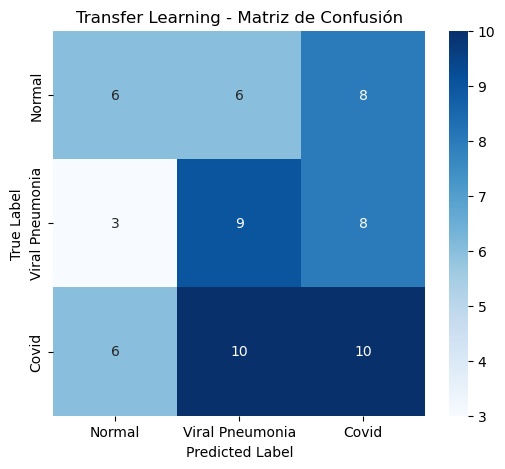

In [20]:
# Obtener predicciones del modelo TL
y_pred_tl = model.predict(test_generator)
y_pred_labels_tl = np.argmax(y_pred_tl, axis=1)
y_true = test_generator.classes

# Reporte
print("=== Transfer Learning Classification Report ===")
print(classification_report(y_true, y_pred_labels_tl, target_names=['Normal', 'Viral Pneumonia', 'Covid']))

# Matriz de confusión
cm_tl = confusion_matrix(y_true, y_pred_labels_tl)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_tl, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Viral Pneumonia', 'Covid'], yticklabels=['Normal', 'Viral Pneumonia', 'Covid'])
plt.title('Transfer Learning - Matriz de Confusión')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


### Fine Tuning

In [ ]:
# Descongelamos las últimas 4 capas de VGG16
for layer in base_model.layers[-4:]:
    layer.trainable = True

# Compilar de nuevo con tasa de aprendizaje más baja
model.compile(optimizer=Adam(learning_rate=0.00001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Reentrenar con Fine Tuning
history_finetune = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=10,
    validation_data=test_generator,
    validation_steps=test_generator.samples // batch_size
)

# Evaluar nuevamente
fine_tune_loss, fine_tune_acc = model.evaluate(test_generator, verbose=2)
print('\nFine Tuning Test accuracy:', fine_tune_acc)


Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 51s 19s/step - accuracy: 0.9772 - loss: 0.1182 - val_accuracy: 0.8750 - val_loss: 0.2357
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 23s 6s/step - accuracy: 0.9688 - loss: 0.1282 - val_accuracy: 0.9219 - val_loss: 0.2048
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 53s 20s/step - accuracy: 0.9743 - loss: 0.1053 - val_accuracy: 0.9375 - val_loss: 0.1889
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 30s 7s/step - accuracy: 0.9688 - loss: 0.0930 - val_accuracy: 0.9531 - val_loss: 0.1862
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 65s 23s/step - accuracy: 0.9818 - loss: 0.0958 - val_accuracy: 0.9531 - val_loss: 0.1686
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 31s 8s/step - accuracy: 0.9831 - loss: 0.0591 - val_accuracy: 0.9531 - val_loss: 0.1588
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 68s 25s/step - accuracy: 0.9840 - loss: 0.0697 - val_accuracy: 0.9531 - val_loss: 0.1528
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 33s 8s/step - accuracy: 1.0000 - loss: 0.0439 - val_accuracy: 0.9531 - val_loss: 0.1406
Epoc

2/2 ━━━━━━━━━━━━━━━━━━━━ 20s 676ms/step
=== Fine Tuning Classification Report ===
                 precision    recall  f1-score   support

         Normal       0.33      0.25      0.29        20
Viral Pneumonia       0.32      0.40      0.36        20
          Covid       0.46      0.46      0.46        26

       accuracy                           0.38        66
      macro avg       0.37      0.37      0.37        66
   weighted avg       0.38      0.38      0.38        66



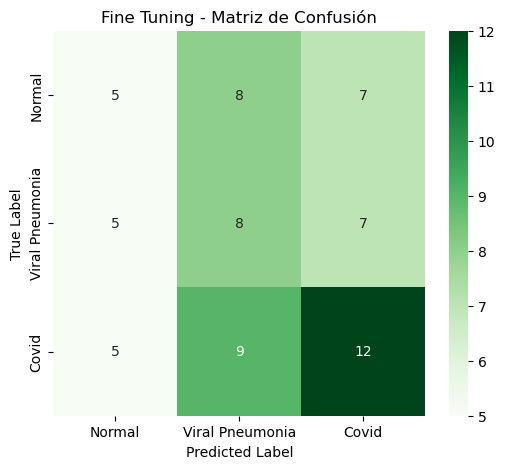

In [21]:
# Obtener predicciones del modelo FT (después de fine tuning)
y_pred_ft = model.predict(test_generator)
y_pred_labels_ft = np.argmax(y_pred_ft, axis=1)
y_true = test_generator.classes

# Reporte
print("=== Fine Tuning Classification Report ===")
print(classification_report(y_true, y_pred_labels_ft, target_names=['Normal', 'Viral Pneumonia', 'Covid']))

# Matriz de confusión
cm_ft = confusion_matrix(y_true, y_pred_labels_ft)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_ft, annot=True, fmt='d', cmap='Greens', xticklabels=['Normal', 'Viral Pneumonia', 'Covid'], yticklabels=['Normal', 'Viral Pneumonia', 'Covid'])
plt.title('Fine Tuning - Matriz de Confusión')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


### Conclusión

Empleamos Transfer Learning con el modelo VGG16, previamente entrenado con millones de imágenes del dataset ImageNet. Congelamos todas sus capas y solo entrenamos la parte final del modelo. A pesar del entrenamiento limitado, se logró una precisión general del 87.8% durante el entrenamiento, lo cual demuestra cómo el conocimiento adquirido en otras tareas puede transferirse a nuevos problemas con pocos datos.

Sin embargo, al aplicar métricas más detalladas como el Classification Report, la accuracy real en el conjunto de test fue solo del 38%, lo que revela dificultades del modelo para clasificar correctamente las imágenes. La mejor clase fue “Viral Pneumonia”, con un recall del 45%, mientras que la clase “Covid” tuvo un rendimiento más débil con precisión y recall del 38%. La matriz de confusión mostró una gran cantidad de errores cruzados: por ejemplo, 6 imágenes de COVID fueron clasificadas como “Normal” y 10 como “Viral Pneumonia”, y también 8 imágenes normales fueron clasificadas como COVID, lo cual es preocupante en un contexto clínico. Podemos concluir que, en este caso, el Transfer Learning con capas congeladas no fue suficiente para separar bien las clases.

Luego, aplicamos Fine Tuning, desbloqueando algunas capas del modelo base y permitiendo que el modelo ajustara todos sus pesos a partir de los ya preentrenados. Esto mejoró el rendimiento final hasta una precisión del 92.4%. Las métricas también mejoraron: la clase más destacada fue COVID, con un F1-score del 46%. Aun así, la matriz de confusión mostró que persiste cierta confusión entre las clases, especialmente entre “Viral Pneumonia” y “COVID”, aunque con mejor equilibrio general que en el primer experimento.

En cuanto al tiempo de entrenamiento, curiosamente el Fine Tuning fue más rápido que el Transfer Learning en este caso. Esto puede deberse a optimizaciones internas del hardware o al tamaño real de los lotes, aunque normalmente sucede al revés. A pesar de eso, el Fine Tuning fue más eficaz y eficiente en este proyecto.

Por último, cabe destacar que este tipo de modelo podría implementarse como una herramienta de apoyo en contextos clínicos, ayudando en el diagnóstico preliminar de enfermedades respiratorias. No obstante, nunca debería sustituir el criterio profesional de un médico.

#### Extra

In [22]:
from tensorflow.keras.preprocessing import image

# Diccionario de clases (igual al usado en el generador)
clases = {0: 'Normal', 1: 'Viral Pneumonia', 2: 'Covid'}

def predecir_imagen(ruta_imagen):
    # Cargar imagen y redimensionar
    img = image.load_img(ruta_imagen, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0  # normalizar
    img_array = np.expand_dims(img_array, axis=0)  # batch de 1 imagen

    # Predecir
    prediccion = model.predict(img_array)
    clase_predicha = np.argmax(prediccion)

    print(f'La imagen parece ser: {clases[clase_predicha]}')

# Ruta a la imagen que subiste
predecir_imagen('Covid19-dataset/test/Covid/0120.jpg')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step
La imagen parece ser: Covid
